# ARIM-Academy：　基礎編　Scikit-learn（次元削減とクラスター分析）

**対象読者：** Python基礎文法を理解している方。`Scikit-learn-5_Classification.ipynb`（分類編）を先に学習していることを前提とします。

**前提知識：** 標準化、train/testの分割、欠損値の除去（`dropna()`）は既習として説明を省略します（本編ではラベルを使わないため、train/test分割自体は行いません）。**次元削減**・**クラスタリング**は初出の用語として説明します。

**動作環境：** Python 3.10以降 / pandas 2.x / numpy 1.26以降 / matplotlib 3.8以降 / seaborn 0.12以降 / scikit-learn 1.2以降 / umap-learn。Google Colabでは`umap-learn`のみ追加インストールが必要です（次のセルで自動的にインストールします）。

**版・ライセンス：** 本ノートブックのコード部分はMITライセンスで提供します。

---

## 本編の目標
本演習では**『茶の元素分析データセット』**（分類編と同じデータ）を用いて、**教師なし学習（Unsupervised Learning）**に分類される**次元削減**と**クラスタリング**の技術を学びます。

> **教師あり学習との違い：** 前編（`Scikit-learn-5_Classification.ipynb`）で扱った決定木・ランダムフォレスト・SVMは、茶葉の品種ラベルを使って学習する教師あり学習でした。本編で扱うPCA・t-SNE・UMAP（次元削減）や階層クラスタリング・k-means（クラスタリング）は、**ラベルを一切使わずに**データの構造を見つけ出す教師なし学習です。可視化の際に品種ラベルで色分けしますが、これはあくまで「教師なしの手法がどれだけ品種の違いを反映した構造を見つけられたか」を人間が確認するためであり、モデル自体はラベルを使っていません。

> **本ノートブックの構成：** 元素分析値（9元素）だけを使った次元削減・クラスタリングは、品種ではなく**抽出濃度・抽出時間による溶出量の違い**を強く反映してしまうことを、実際のデータで確認していきます。今回のデータセットには実際の抽出条件（`Concentration`：抽出濃度、`time`：抽出時間）が記録されているため、その影響を統計的に取り除いたうえで、あらためて品種による違いを捉え直せるかを最後に検証します。

### 本編における内容
1. **データ前処理**：欠損値（抽出条件が記録されていない79件）を`dropna()`で除去します。
2. **次元削減技術の学習**: 高次元データを低次元に変換する次元削減手法（主成分分析（PCA）、t-SNE、UMAP）を学びます。
3. **クラスタリングアルゴリズムの理解**: クラスタリング手法（階層クラスタリングやK-means）を使用して、データセット内の類似性、グループやパターンを識別します。
4. **交絡要因（抽出条件）の影響の除去**: 抽出濃度・抽出時間という既知の実験条件が、次元削減・クラスタリングの結果をどれだけ支配しているかを検証し、その影響を除去したうえで品種による違いを再検討します。

---

## データセット
分類編と同じ**『茶の元素分析データセット』**を使用します。4品種×3抽出濃度×7抽出時間×2反復＝168件（有効データ）に加え、抽出条件が記録されていない欠損行が79件含まれています。データセットの詳細は`Scikit-learn-5_Classification.ipynb`を参照してください。

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
%pip install umap-learn

! pip install matplotlib_fontja
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_1_scikit-learn.git
%cd Advanced_Tutorial_1_scikit-learn

# 1. データセットの読み込みと前処理

### ライブラリのインポート
カリキュラムで扱うpythonのライブラリを`import`文でロードします。機械学習のライブラリであるscikit-learnは後半でimportします。

In [1]:
#ライブラリ
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### サンプルファイルの読み込み
pandasライブラリの`read_csv()`はcsvファイルを読み込むメソッドであり、指定したファイルを読み込みます。ここでは[data]フォルダーに格納されている`tea_data_2.csv`のファイルをデータフレームとして読み込み、そのデータフレームは`df`という変数に格納します。

In [2]:
#データセットの読み込み
df=pd.read_csv("data/tea_data_2.csv")
df

,Al,Ca,Cu,Fe,K,Mg,Mn,Na,Zn,Concentration,time,tea
0,3.297,4.356,0.031290,0.067,99.06,3.531,1.455,0.541,0.131,1%,2,BT
1,4.267,4.118,0.031290,0.079,106.50,3.378,1.542,0.603,0.126,1%,2,BT
2,4.088,4.763,0.033370,0.084,114.00,4.763,1.838,1.058,0.156,1%,5,BT
3,4.338,4.556,0.033370,0.091,122.60,5.005,2.269,0.958,0.162,1%,5,BT
4,4.732,5.138,0.035514,0.110,132.40,5.626,2.998,1.510,0.165,1%,10,BT
...,...,...,...,...,...,...,...,...,...,...,...,...
163,16.690,8.895,0.153000,0.236,323.40,20.450,10.420,6.360,0.335,3%,30,GC
164,17.620,8.909,0.177000,0.261,334.20,23.486,11.330,7.133,0.351,3%,45,GC
165,17.920,9.056,0.180000,0.266,332.30,22.840,11.290,7.609,0.358,3%,45,GC
166,17.820,9.128,0.175000,0.273,367.30,24.560,12.110,8.537,0.372,3%,60,GC


### データセットの分割（数値データ部とラベル部）
教師なし学習では訓練/テストへの分割は行いませんが、9つの数値データ（説明変数）とラベル（茶の品種）は分けて扱います。ラベル`y`は、次元削減やクラスタリングの計算そのものには使わず、**結果を可視化する際に色分けするためだけ**に使います。

また、後半で使う抽出条件（**抽出濃度**`Concentration`・**抽出時間**`time`）も、`conditions`として別に取り出しておきます。`Concentration`は`'1%'`のような文字列なので、数値に変換します。

In [53]:
# 数値データ部とラベル部の用意をしましょう
X = df.drop(['tea', 'Concentration', 'time'], axis=1)  # 元素分析データ（Al, Ca, Cu, Fe, K, Mg, Mn, Na, Zn）
y = df['tea']                                            # 茶の品種（ラベル、可視化の色分けにのみ使用）

# 抽出条件（後半で使用）
conditions = pd.DataFrame({
    'Concentration_num': df['Concentration'].str.rstrip('%').astype(float),
    'time': df['time']
})

In [54]:
X

,Al,Ca,Cu,Fe,K,Mg,Mn,Na,Zn
0,3.297,4.356,0.031290,0.067,99.06,3.531,1.455,0.541,0.131
1,4.267,4.118,0.031290,0.079,106.50,3.378,1.542,0.603,0.126
2,4.088,4.763,0.033370,0.084,114.00,4.763,1.838,1.058,0.156
3,4.338,4.556,0.033370,0.091,122.60,5.005,2.269,0.958,0.162
4,4.732,5.138,0.035514,0.110,132.40,5.626,2.998,1.510,0.165
...,...,...,...,...,...,...,...,...,...
163,16.690,8.895,0.153000,0.236,323.40,20.450,10.420,6.360,0.335
164,17.620,8.909,0.177000,0.261,334.20,23.486,11.330,7.133,0.351
165,17.920,9.056,0.180000,0.266,332.30,22.840,11.290,7.609,0.358
166,17.820,9.128,0.175000,0.273,367.30,24.560,12.110,8.537,0.372


In [55]:
y

0      BT
1      BT
2      BT
3      BT
4      BT
       ..
163    GC
164    GC
165    GC
166    GC
167    GC
Name: tea, Length: 168, dtype: str

# 2. 次元削減
**次元削減**は、教師なし学習の一種としてデータ分析や機械学習において重要な手法で、データの持つ特徴量の数を削減し、データの本質的な構造や情報を維持しつつ、データの理解や視覚化を容易にする技術です。  

### 次元削減の種類
ここでは、線形次元削減である主成分分析（PCA）および非線形次元削減（多様体学習法）のt-分布型確率的近傍埋め込み（t-SNE）と統一マニホールド近似と射影（UMAP）について説明します。

1. **PCA(主成分分析)** :  
   PCAは線形次元削減手法であり、データの分散を最大化する直交する軸（主成分）を見つけます。PCAはデータの分布の最も重要な方向を特定し、特徴量間の関連性を明らかにします。PCAはデータの線形な関係性を捉えるのに適しています。

2. **t-SNE（t-分布型確率的近傍埋め込み）**:  
    t-SNEは、非線形次元削減手法であり、特にデータのクラスタリング構造を視覚化するのに優れています。t-SNEは高次元データの局所的な構造を低次元空間に保持し、データポイント間の類似性を視覚的に表現します。

3. **UMAP（統一マニホールド近似と射影）**:  
    UMAPは、t-SNEと同様に非線形次元削減手法で、データの局所的および大域的な構造を保持しつつ、次元を削減します。UMAPは計算が速く、大規模データセットにも適用可能です。

## 1. 主成分分析
次元削減の一番汎用的な手法である「主成分分析」を行ってみましょう。

### ①　モデル構築
PCAクラスは、Scikit-learnライブラリから提供される主成分分析のクラスです。主成分分析では、データの次元を削減し、データの最も重要な変動を捉えるモデルを構築します。

まずは、標準化を**行わずに**そのままのデータでPCAを実行してみます（この後、標準化した場合と比べます）。

In [56]:
from sklearn.decomposition import PCA

In [57]:
# 主成分分析（PCA）で2次元に次元削減（標準化なし）
pca = PCA(n_components=2)  # 2次元に次元削減
X_pca = pca.fit_transform(X)

### 【解説】PCAのハイパーパラメータ
主成分分析（PCA）は、データの次元を削減するための手法であり、データの分散を最大化する直交する軸（主成分）を見つけます。PCAには少数のハイパーパラメータがあり、それらを適切に設定することで次元削減の結果を調整できます。以下はPCAの主なハイパーパラメータです。

1. **`n_components`**
- **説明**: 保持する主成分の数を指定します。これにより、次元削減後のデータセットの次元数が決定されます。
  - **整数値**: 保持する主成分の数を指定。例えば、`n_components=2`なら、2次元に削減されます。
  - **0 < n_components < 1 の小数値**: 累積寄与率が指定された値に達するまで主成分を保持。例えば、`n_components=0.95`なら、データの95%の分散を説明するのに十分な数の主成分が保持されます。
  - **`None`**: すべての成分が保持されますが、次元削減は行われません。
- **デフォルト値**: `None`

2. **`svd_solver`**
- **説明**: 特異値分解（SVD）を行うためのアルゴリズムを指定します。データのサイズや特性に応じて適切なアルゴリズムを選択します。
  - **`auto`**: デフォルトで、データセットのサイズに基づいて最適なアルゴリズムを選択します。
  - **`full`**: 完全なSVDを計算します。データが少ない場合や精度が求められる場合に使用します。
  - **`randomized`**: ランダム化されたSVDを計算します。高速で、大規模データに適しています。

3. **`whiten`**
- **説明**: `True`に設定すると、主成分が分散1になるようにスケーリングされます。
- **デフォルト値**: `False`

4. **`random_state`**
- **説明**: `svd_solver='randomized'`の場合に使用される乱数シード。再現性のために設定します。
- **デフォルト値**: `None`

### その他の考慮事項
- **データの標準化**: PCAを実行する前にデータを標準化することが一般的です。これは、各特徴量のスケールが異なる場合に、主成分の抽出がそのスケールの影響を受けるのを防ぐためです。次のセクションで、標準化の有無による結果の違いを実際に確認します。

### ②　二次元プロット（可視化）

次元削減の結果を視覚化するためのグラフです。主成分分析では**スコアプロット**とも呼ばれ、データのクラスタリングやクラス間の分離状態を確認でき、PCAによって次元削減がどれだけ有効であったかを直感的に理解することができます。

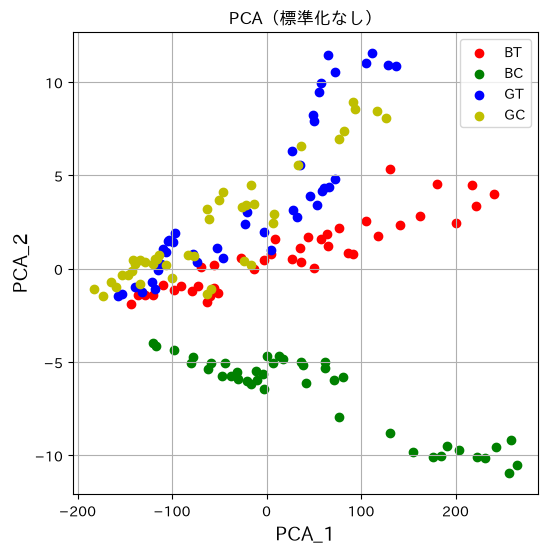

In [58]:
# PCAのプロット（標準化なし）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_pca[y == specie, 0], X_pca[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('PCA_1', fontsize =14)
plt.ylabel('PCA_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('PCA（標準化なし）')
plt.show()

In [60]:
# 標準化なしの場合、PC1だけでどれだけの分散を説明しているか、
# また、どの元素がPC1を支配しているかを確認してみましょう
print('寄与率（標準化なし）:', np.round(pca.explained_variance_ratio_, 3))
print()
print('PC1の各元素の重み（絶対値が大きいほど影響大）:')
print(pd.Series(pca.components_[0], index=X.columns).sort_values())

寄与率（標準化なし）: [0.997 0.002]

PC1の各元素の重み（絶対値が大きいほど影響大）:
Cu    0.000105
Fe    0.000231
Zn    0.000738
Ca    0.005871
Na    0.009524
Mn    0.019012
Al    0.029193
Mg    0.068693
K     0.996966
dtype: float64


結果を見ると、**PC1だけでほぼ100%の分散を説明**しており、しかもPC1の重みはほぼ`K`（カリウム）だけで決まっていることが分かります。これは「PCAが本当に9元素すべての情報をバランスよく統合した」のではなく、**単に一番数値の大きい`K`（濃度が他の元素より2桁近く大きい）にPCAが引きずられているだけ**であることを意味します。次に、標準化してから同じことをやり直してみましょう。

### ③　標準化
PCAは、データのスケールに敏感であるため、次元削減の前に標準化が必要です。標準化では、各特徴量を平均0、標準偏差1にスケーリングし、異なるスケールを持つ特徴量が等しく扱われるようにします。これにより、PCAが特徴量のスケールに依存せず、データ全体の構造を正確に反映できます。

In [61]:
from sklearn.preprocessing import StandardScaler

In [62]:
# データの標準化
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [63]:
# 主成分分析（PCA）：後の寄与率の確認のため、9つの主成分すべてを計算する
pca = PCA(n_components=9)  
X_pca = pca.fit_transform(X_std)

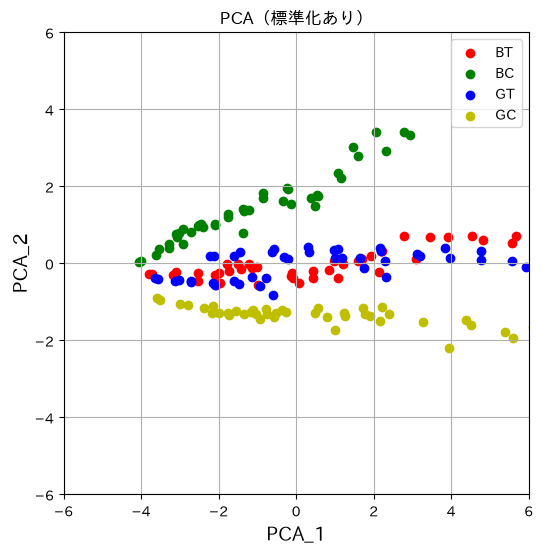

In [64]:
# PCAのプロット（標準化あり、PC1・PC2のみ表示）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_pca[y == specie, 0], X_pca[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('PCA_1', fontsize =14)
plt.ylabel('PCA_2', fontsize =14)
plt.xlim(-6,6)
plt.ylim(-6, 6)

plt.legend()
plt.grid()
plt.title('PCA（標準化あり）')
plt.show()

### 標準化の効果を数値で確認する
標準化した場合の寄与率を見てみましょう。標準化前は「PC1だけでほぼ100%」でしたが、標準化後はどう変わるでしょうか。

In [68]:
# 標準化なしの場合、PC1だけでどれだけの分散を説明しているか、
# また、どの元素がPC1を支配しているかを確認してみましょう
print('寄与率（標準化なし）:', np.round(pca.explained_variance_ratio_, 3))
print('PC1が説明する分散の割合:', round(pca.explained_variance_ratio_[0]*100, 1), '%（標準化前は99.7%でした）')
print()
print('PC1の各元素の重み（絶対値が大きいほど影響大）:')
print(pd.Series(pca.components_[0], index=X.columns).sort_values())

寄与率（標準化なし）: [0.717 0.14  0.077 0.029 0.021 0.007 0.006 0.002 0.002]
PC1が説明する分散の割合: 71.7 %（標準化前は99.7%でした）

PC1の各元素の重み（絶対値が大きいほど影響大）:
Cu    0.261085
K     0.301115
Mg    0.312425
Fe    0.339395
Ca    0.343823
Al    0.347737
Na    0.349047
Zn    0.364655
Mn    0.366639
dtype: float64


標準化後は、PC1が説明する分散の割合が大きく下がり、PC2以降も意味のある情報を持つようになったことが分かります。標準化前のPCAは実質的に「Kの量だけを見ている」に等しく、品種間の分離もはっきりしませんが、標準化後のグラフでは4品種がある程度分かれて分布している様子が見えるはずです。**PCAを使うときは、原則として標準化してから行うべき**であることが、この比較から実感できます。

### ④　寄与率と累積寄与率
PCAでは、データセットの特徴量を直交する新たな軸（主成分）に変換しますが、それぞれの主成分は、元のデータの分散（情報量）をどの程度説明できるかを示す寄与率を持ちます。例えば、寄与率が0.4であれば、その主成分だけで元のデータの40%の分散を説明できることを意味します。累積寄与率は、最初のn個の主成分まででどれだけの分散を説明できるかを示します。累積寄与率が1に近づくほど、それまでの主成分がほぼ全ての分散を説明していることを意味します。

pythonでは`explained_variance_ratio_`からは各主成分の寄与率を計算できます。`np.cumsum()`メソッドより累積寄与率を計算します。

In [16]:
# 寄与率の計算
explained_variance_ratio = pca.explained_variance_ratio_

# 累積寄与率の計算
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

In [17]:
explained_variance_ratio

array([0.71650408, 0.13997561, 0.07671744, 0.02861021, 0.02109378,
       0.00737171, 0.00557342, 0.00230621, 0.00184754])

In [18]:
cumulative_explained_variance

array([0.71650408, 0.85647969, 0.93319713, 0.96180734, 0.98290112,
       0.99027283, 0.99584625, 0.99815246, 1.        ])

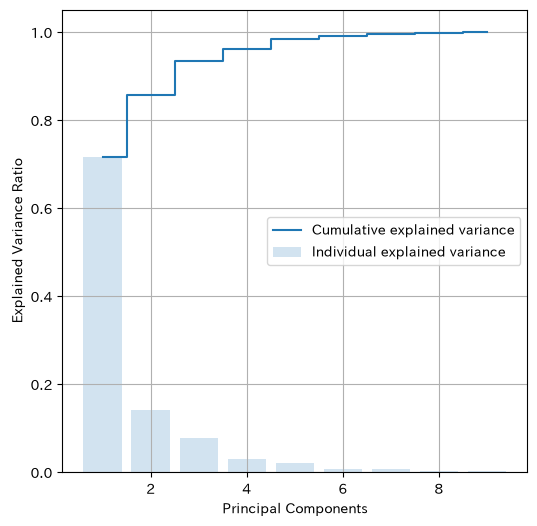

In [19]:
# 寄与率のプロット
plt.figure(figsize=(6, 6))

plt.bar(range(1, 10), explained_variance_ratio, alpha=0.2, align='center',
        label='Individual explained variance')

plt.step(range(1, 10), cumulative_explained_variance, where='mid',
         label='Cumulative explained variance')

plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')

plt.legend()
plt.grid()
plt.show()

## 2. t-分布型確率的近傍埋め込み（t-SNE）
t-分布型確率的近傍埋め込み（t-SNE）は、高次元データを低次元空間に効果的に埋め込む手法です。この手法は、データポイント間の局所的な類似性を保持しながら、データの高次元構造を視覚化します。

In [69]:
from sklearn.manifold import TSNE

### ①　モデル構築
t-SNEクラスは、Scikit-learnライブラリから提供されるt-分布型確率的近傍埋め込みのクラスです。このクラスを使用して、高次元データを低次元空間に埋め込み、データの局所的な構造を保持しながら視覚化します。t-SNEは、データポイント間の類似性を反映する2次元または3次元のプロットを生成し、複雑なデータのパターンを理解するのに役立ちます。

In [70]:
# t-SNEの実行（標準化なし）
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

### 【解説】t-SNEの主なハイパーパラメータ

| パラメータ | 説明 | デフォルト値 |
| --- | --- | --- |
| `n_components` | 埋め込み後の次元数。通常2または3。 | 2 |
| `perplexity` | 近傍とみなす点の数の目安。小さいと局所的構造、大きいと大域的構造を重視。データ数に応じて5〜50程度で調整。 | 30 |
| `learning_rate` | 埋め込み空間での更新のステップサイズ。小さすぎると収束が遅く、大きすぎると発散する可能性がある。 | 200（自動調整の場合あり） |
| `n_iter` | 最適化の反復回数。通常1000回以上が推奨される。 | 1000 |
| `init` | 埋め込みの初期化方法。`'random'`または`'pca'`。 | `'pca'`（新しいバージョンでは`'pca'`が既定になっています） |
| `metric` | データ間の距離指標。ユークリッド距離（`'euclidean'`）など。 | `'euclidean'` |
| `random_state` | 再現性のための乱数シード。 | `None` |

特に`perplexity`と`learning_rate`は結果の見た目に大きく影響するため、いくつかの値を試して比較することが推奨されます。

### ②　二次元プロット（可視化）

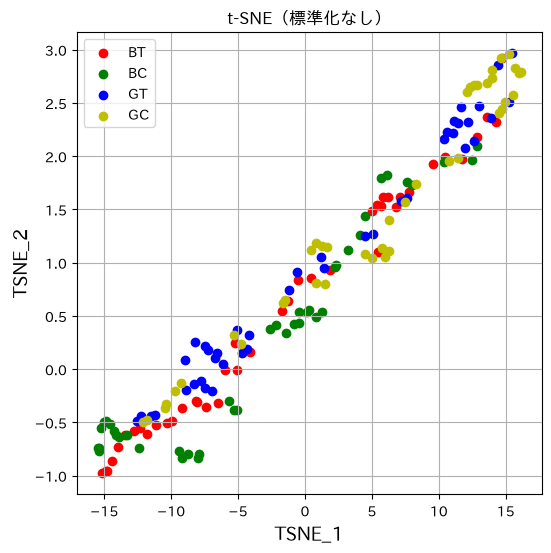

In [22]:
# t-SNEのプロット（標準化なし）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_tsne[y == specie, 0], X_tsne[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('TSNE_1', fontsize =14)
plt.ylabel('TSNE_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('t-SNE（標準化なし）')
plt.show()

### ③　標準化

t-分布型確率的近傍埋め込み（t-SNE）を適用する際には、データの標準化が推奨されます。標準化を進めることで、データのスケールによる偏りを防ぎ、より正確で意味のある可視化を得ることができます。標準化を行わないと、データのスケールによってt-SNEの結果が歪む可能性があります。その影響を、PCAのときと同様に比較してみましょう。

In [23]:
X_tsne_std = tsne.fit_transform(X_std)

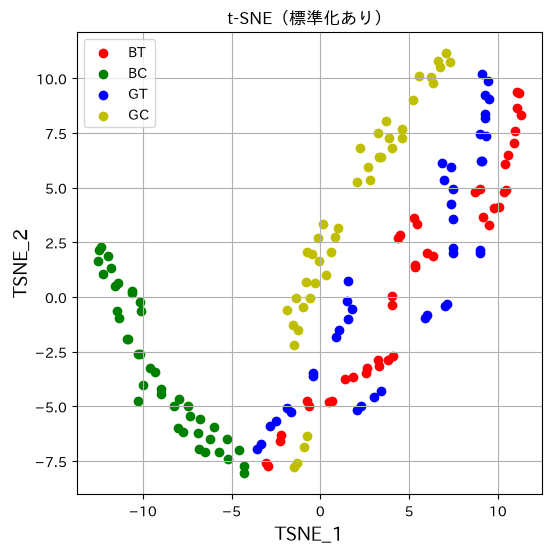

In [24]:
# t-SNEのプロット（標準化あり）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_tsne_std[y == specie, 0], X_tsne_std[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('TSNE_1', fontsize =14)
plt.ylabel('TSNE_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('t-SNE（標準化あり）')
plt.show()

PCAほど劇的な違いではありませんが、標準化の有無でクラスタの見え方（品種ごとの固まりの分離具合）が変わることを確認してください。t-SNEは距離をベースにした手法のため、PCAと同様にスケールの影響を受けます。

## 3. 統一マニホールド近似と射影（UMAP）
統一マニホールド近似と射影（UMAP）は、高次元データを低次元空間に効率的に埋め込む手法です。UMAPは、データの局所的な構造と全体的な構造を保持しながら、複雑なデータの可視化を行います。

In [25]:
from umap import UMAP

### ①　モデル構築
UMAPクラスは、umap-learnライブラリから提供される統一マニホールド近似と射影の実装クラスです。このクラスを使用して、高次元データを低次元空間に効果的に埋め込むことができます。

In [26]:
# UMAPの実行（標準化なし）
umap_model = UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X)

### 【解説】UMAPの主なハイパーパラメータ

| パラメータ | 説明 | デフォルト値 |
| --- | --- | --- |
| `n_neighbors` | 近傍点の数。小さいと局所構造、大きいと大域構造を強調。5〜50程度が目安。 | 15 |
| `min_dist` | 埋め込み空間での点同士の最小距離。小さいと密集、大きいと疎になる。 | 0.1 |
| `n_components` | 埋め込み後の次元数。 | 2 |
| `metric` | 距離指標（`'euclidean'`など）。 | `'euclidean'` |
| `random_state` | 再現性のための乱数シード。 | `None` |

`n_neighbors`と`min_dist`は結果への影響が大きいため、特に注目すべきパラメータです。

### ②　二次元プロット（可視化）

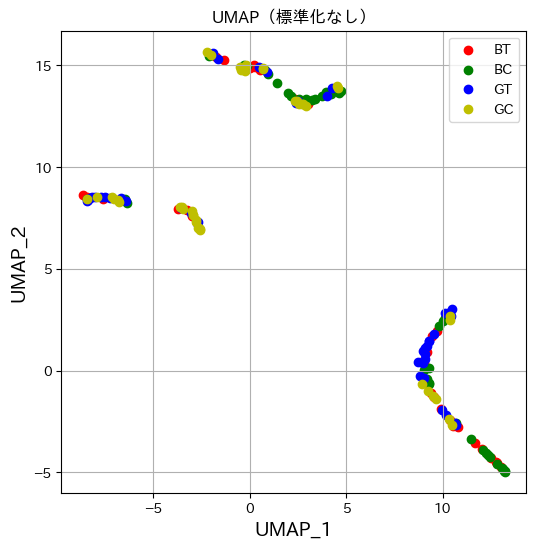

In [28]:
# UMAPのプロット（標準化なし）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_umap[y == specie, 0], X_umap[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('UMAP_1', fontsize =14)
plt.ylabel('UMAP_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('UMAP（標準化なし）')
plt.show()

### ③　標準化

UMAPについても、PCA・t-SNEと同様に標準化が推奨されます。ここでも標準化を通じた影響について比較してみましょう。

In [29]:
X_umap_std = umap_model.fit_transform(X_std)

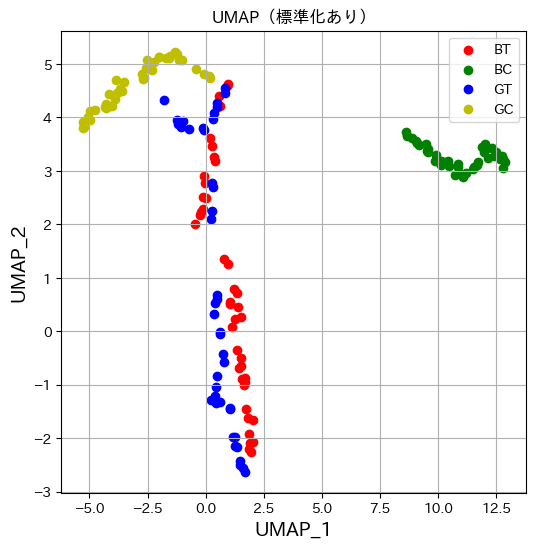

In [30]:
# UMAPのプロット（標準化あり）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_umap_std[y == specie, 0], X_umap_std[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('UMAP_1', fontsize =14)
plt.ylabel('UMAP_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('UMAP（標準化あり）')
plt.show()

# 3. クラスタリング
**クラスタリング**とは、データをいくつかのグループ（クラスター）に分けるデータ分析手法の一つです。この手法では、同じクラスターに属するデータポイントが互いに類似しており、異なるクラスターのデータポイントとの間には顕著な違いがあるようにします。クラスタリングは、教師なし学習の一種で、事前にラベルが付けられていないデータのパターンを識別するために使用されます。

### クラスタリングの特徴
クラスタリングにはさまざまな方法があり、データの特性や目的に応じて適切なアルゴリズムが選択されます。主なクラスタリング手法には以下があります。

1. **階層クラスタリング**：  
    データポイントを階層的にグループ化する方法です。凝集型（アグロメレイティブ）クラスタリングと分割型（ディバイシブ）クラスタリングに分かれます。結果はデンドログラムとして視覚化され、クラスターの形成過程を視覚的に確認できます。

2. **K-平均法 (K-means）**:  
   事前に設定したクラスター数`k`にデータを分ける方法です。アルゴリズムは、各データポイントを最も近いクラスターの重心に割り当て、クラスターの中心（重心）が最適化されるまで繰り返します。

## 1.階層クラスタリング分析
階層クラスタリングは、データを階層的にグループ化するためのクラスタリング手法です。階層クラスタリングの結果は、デンドログラムと呼ばれるツリーストラクチャーで視覚化されます。デンドログラムでは、クラスターがどのようにして結合されたのか（または分割されたのか）、またクラスター間の距離がどれくらいかが示されます。

> **標準化について：** 後述の「その他の考慮事項」で述べる通り、距離ベースのクラスタリングでは標準化が推奨されます。本データセットは元素ごとの濃度スケールが大きく異なるため（例：Kは100前後、Cuは0.1未満）、ここでは最初から標準化したデータ`X_std`を使います。

In [74]:
from scipy.cluster.hierarchy import linkage, dendrogram

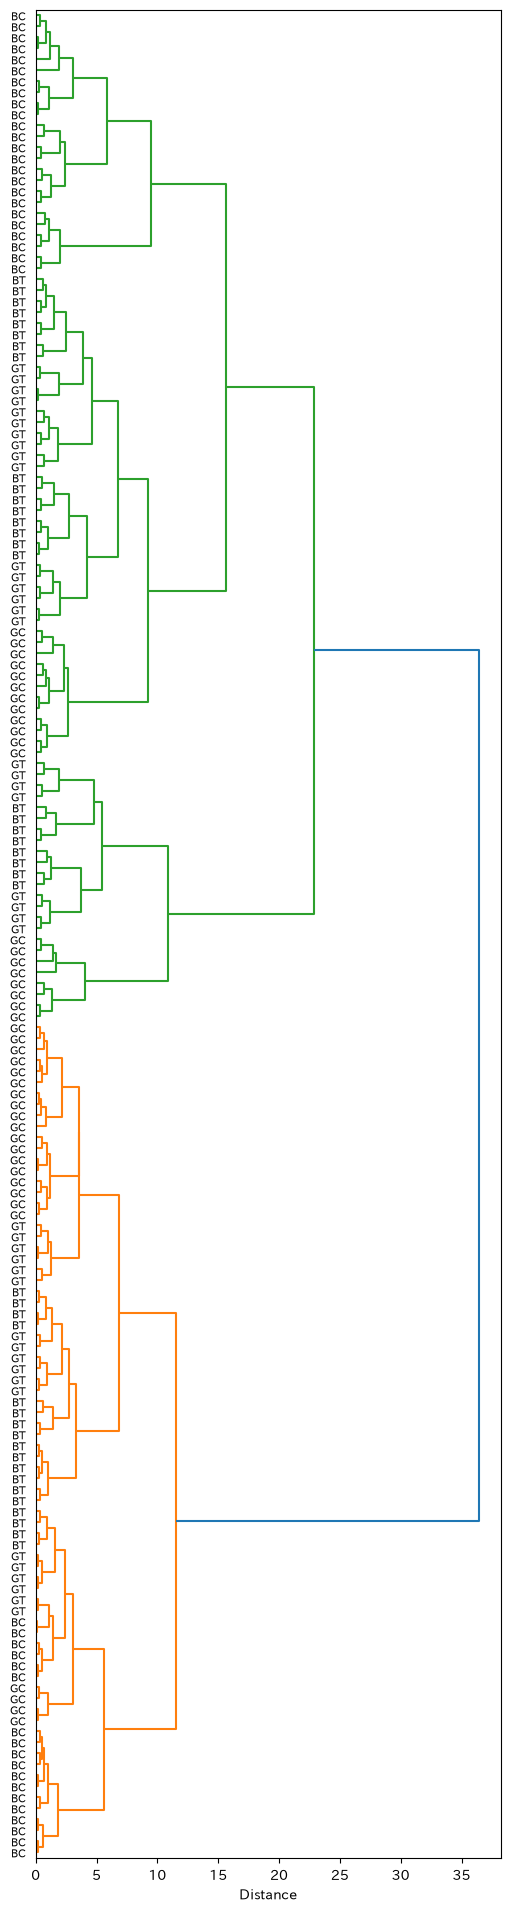

In [75]:
plt.figure(figsize=(6, 24))

# 階層クラスタリング（標準化済みデータを使用）
linkage_matrix = linkage(X_std, method='ward')

dendrogram(linkage_matrix, 
           labels = y.tolist(), 
           orientation = 'right',
          )

plt.xlabel('Distance')
plt.yticks(fontsize=8)  # 品種のフォントサイズを8に設定
plt.show()

### 色分けの意味を確認する

上のデンドログラムは緑とオレンジの2色に分かれていますが、これは**4品種を表しているわけではありません**。scipyの`dendrogram()`関数は、デフォルトでは「最も高い結合距離（一番上の分岐）の70%」を閾値として、それより低い位置にある枝だけを色分けし、閾値より高い位置にある枝（幹に近い部分）は既定の色（青）でまとめて表示します。**この閾値は品種の数（4）とは何の関係もなく、単なる距離のルールです。**

今回のデンドログラムでは、この既定の閾値によってちょうど2色（＝2グループ）に分かれています。これが何を意味しているのか、実際に確認してみましょう。

In [76]:
from scipy.cluster.hierarchy import fcluster

# デフォルトのcolor_threshold（0.7×最大結合距離）で2グループに分けたときの中身を確認
default_threshold = 0.7 * linkage_matrix[:,2].max()
clusters_2 = fcluster(linkage_matrix, t=default_threshold, criterion='distance')

print('デフォルトの色分け（2グループ）の品種内訳:')
print(pd.crosstab(pd.Series(clusters_2, name='cluster'), y))

print()
print('各グループの標準化濃度合計の平均:')
for c in sorted(set(clusters_2)):
    print(f'グループ{c}: 濃度合計平均={X_std.sum(axis=1)[clusters_2==c].mean():.2f}  件数={ (clusters_2==c).sum() }')

デフォルトの色分け（2グループ）の品種内訳:
tea      BC  BT  GC  GT
cluster                
1        18  18  22  18
2        24  24  20  24

各グループの標準化濃度合計の平均:
グループ1: 濃度合計平均=-6.46  件数=76
グループ2: 濃度合計平均=5.34  件数=92


内訳を見ると、それぞれのグループに4品種がほぼ均等に混ざっています。一方で「濃度合計の平均」を見ると、片方が明確に低く、もう片方が明確に高くなっているはずです。**つまり、このデンドログラムの一番大きな（幹に近い）分岐は、k-meansのエルボー法（k=2）のときと全く同じ理由——「抽出濃度の高低」——で色分けされている**ことが分かります。標準化データに対してユークリッド距離ベースで階層クラスタリングを行う限り、データの中で最も分散が大きい方向（＝濃度）が、真っ先に大きな分岐として現れるのは自然なことです。

では、品種（4種類）に合わせて木を切ったら、色分けはどう変わるでしょうか。

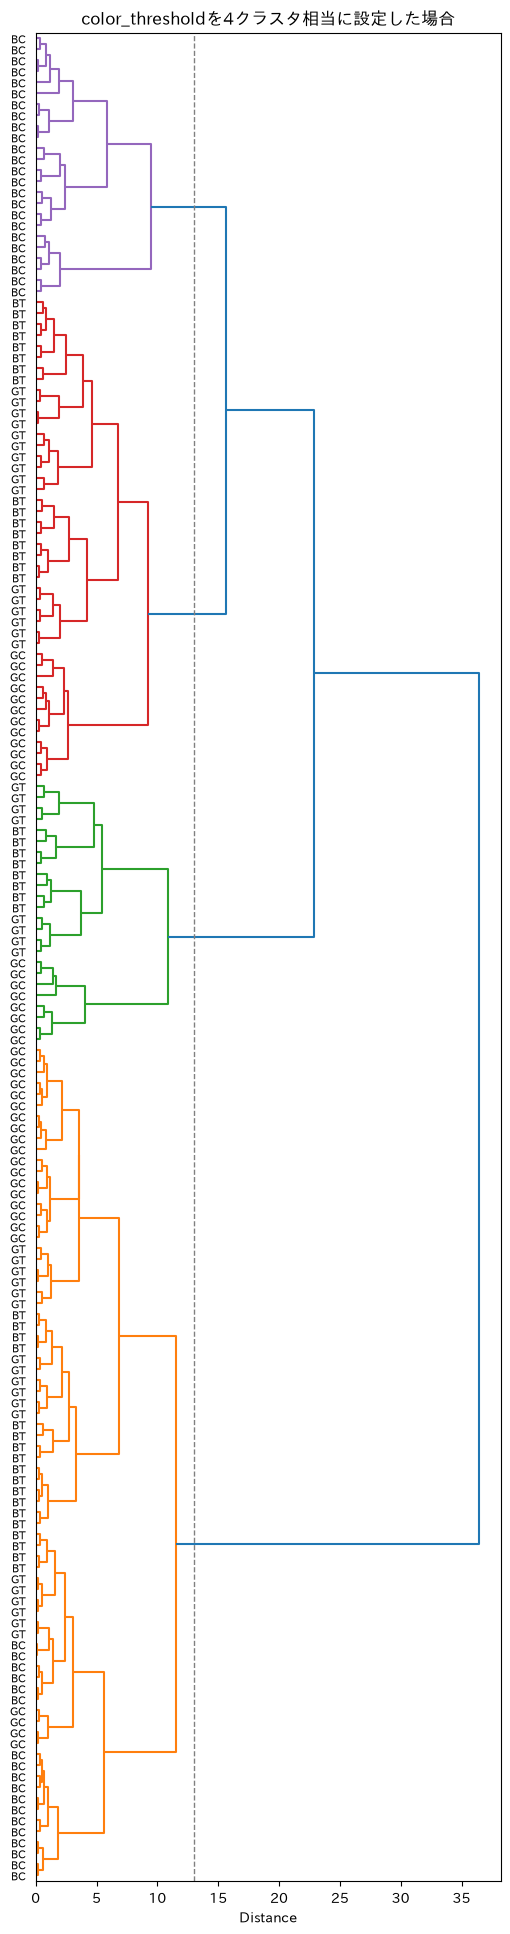

In [77]:
# 4品種に合わせて、あえて4グループになる位置に色分けの閾値を設定する
plt.figure(figsize=(6, 24))

dendrogram(linkage_matrix,
           labels=y.tolist(),
           orientation='right',
           color_threshold=13,   # 4クラスタに分かれる距離帯（11.56〜15.65）の中央付近
          )

plt.xlabel('Distance')
plt.yticks(fontsize=8)
plt.axvline(x=13, color='gray', linestyle='--', linewidth=1)
plt.title('color_thresholdを4クラスタ相当に設定した場合')
plt.show()

In [78]:
# 実際に4クラスタに切った場合の品種内訳
clusters_4 = fcluster(linkage_matrix, t=4, criterion='maxclust')
print('4クラスタに切った場合の品種内訳:')
print(pd.crosstab(pd.Series(clusters_4, name='cluster'), y))

4クラスタに切った場合の品種内訳:
tea      BC  BT  GC  GT
cluster                
1        18  18  22  18
2         0   8   8   8
3         0  16  12  16
4        24   0   0   0


4クラスタに切ると、k-meansのk=4のときとよく似た結果になっているはずです：1つはブラックセイロン(BC)だけの比較的純粋なグループになり、残りはBT・GC・GTが混ざったグループに分かれます（濃度による副次的な区切りが依然として影響しています）。品種情報が全くないわけではなく、**「木のどの高さで色分けするか」によって、見えてくる構造が変わる**ということです。

試しに、さらに細かく（16グループ程度に）切ってみると、ブラックセイロン(BC)やグリーンセイロン(GC)を中心に、より品種に近い小さな塊がいくつか現れてきます。品種による違いは、データの中で"支配的"ではないものの、確かに存在しているということです。

In [79]:
# さらに細かく16グループに切ってみる
clusters_16 = fcluster(linkage_matrix, t=16, criterion='maxclust')
tbl16 = pd.crosstab(pd.Series(clusters_16, name='cluster'), y)
print('16クラスタに切った場合の品種内訳:')
print(tbl16)
print()
# 各グループが単一品種でどれだけ占められているか（最大割合）を確認
purity = tbl16.max(axis=1) / tbl16.sum(axis=1)
print('各グループの「最も多い品種の割合」（1.0=単一品種のみ）:')
print(purity)

16クラスタに切った場合の品種内訳:
tea      BC  BT  GC  GT
cluster                
1        12   0   0   0
2         6   4   4   6
3         0  14   0   6
4         0   0  18   6
5         0   0   8   0
6         0   4   0   4
7         0   4   0   0
8         0   0   0   4
9         0   0  12   0
10        0   0   0   6
11        0   8   0   0
12        0   0   0   6
13        0   8   0   4
14        6   0   0   0
15        8   0   0   0
16       10   0   0   0

各グループの「最も多い品種の割合」（1.0=単一品種のみ）:
cluster
1     1.000000
2     0.300000
3     0.700000
4     0.750000
5     1.000000
6     0.500000
7     1.000000
8     1.000000
9     1.000000
10    1.000000
11    1.000000
12    1.000000
13    0.666667
14    1.000000
15    1.000000
16    1.000000
dtype: float64


**まとめ：デンドログラムの色は「4品種」を意味する保証はない。** scipyの既定の色分けは、単に距離の70%地点で機械的に切っているだけで、今回はたまたま「濃度の高低」という、品種とは無関係な軸を反映していました。デンドログラム自体（木の形）にはより詳細な情報が含まれていますが、それを何色に塗るか、どの高さで切るかは分析者が目的に応じて選ぶ必要があります。品種を確認したい場合は、上のように`fcluster()`で品種数に合わせてクラスタを切り出し、実際のラベルと突き合わせて確認するのが確実です。

### 【解説】階層クラスタリングのハイパーパラメータ
階層クラスタリングは、データの階層的な構造を表現するクラスタリング手法で、クラスタの数を事前に指定する必要がありません。階層クラスタリングの主なハイパーパラメータは、以下のようにクラスタリングの手法とクラスタ間の距離をどのように定義するかに関するものです。

1. **`method`（linkage法）**
- **説明**: クラスタ間の距離をどのように計算するかを指定します。以下のような様々な手法があります:
  - **`single`**: シングルリンク法。最も近いポイント間の距離をクラスタ間の距離とする。
  - **`complete`**: コンプリートリンク法。最も遠いポイント間の距離をクラスタ間の距離とする。
  - **`average`**: 平均リンク法。すべてのペアの平均距離をクラスタ間の距離とする。
  - **`ward`**: ウォード法。全体の分散が最小になるようにクラスタを結合します。デフォルトではこの手法がよく用いられます。

2. **`metric`（距離メトリック）**
- **説明**: データポイント間の距離を計算するためのメトリックを指定します。以下のようなオプションがあります:
  - **`euclidean`**: ユークリッド距離。最も一般的に使用される距離メトリック。
  - **`manhattan`**: マンハッタン距離。各軸に沿った距離の合計。
  - **`cosine`**: コサイン距離。ベクトル間の角度に基づく距離。

3. **`criterion`（停止基準）**
- **説明**: クラスタリングを終了する条件を指定します。一般的なものには以下があります:
  - **`distance`**: 距離のしきい値を指定してクラスタの結合を停止する。
  - **`maxclust`**: 指定されたクラスタ数に達するまでクラスタの結合を続ける。

### その他の考慮事項
- **データの標準化**: 距離ベースのクラスタリング手法では、各特徴のスケールの違いが影響を与えるため、特徴量の標準化やスケーリングが推奨されます。

これらのハイパーパラメータを調整することで、クラスタリングの結果やデンドログラムの解釈が大きく変わります。特に`method`と`metric`の選択は、クラスタリングの特性やデータの構造に大きな影響を与えるため、データの特性に応じて適切に選択することが重要です。

## 2. k-平均法（k-means）
K-平均法の目的は、データセット内のオブジェクトを指定された数（K）のクラスタに分割することです。クラスタは、データの中心点（平均）に基づいて形成されます。このアルゴリズムは以下の手順で実行されます。

まず、K個のクラスタ中心（セントロイド）をランダムに選定します。次に、各データポイントを最も近いクラスタ中心に割り当てます。この際、ユークリッド距離などの距離指標に基づいて、データポイントは最も近いクラスタ中心に属します。その後、各クラスタに属するデータポイントの平均を計算し、新しいクラスタ中心として設定します。このプロセスを、クラスタ中心がほとんど変化しなくなるか、変更が指定された閾値以下になるまで繰り返します。

> **このセクションで確認すること：** k-meansは「ラベルを一切見ずに、数値データの構造だけからグループを見つける」教師なし学習です。この節では、(1) 何個のグループに分けるのが妥当かをエルボー法で検討したあと、(2) 次元削減（UMAP）と組み合わせて結果を可視化する際に生じる落とし穴と、(3) より適切な代替手法を、実際の数値で確認していきます。

In [80]:
from sklearn.cluster import KMeans

### ①　モデル構築
KMeansクラスは、scikit-learnライブラリから提供されるクラスタリングアルゴリズムの実装クラスです。このクラスを使用して、データを指定した数のクラスタに分割することができます。標準化済みの`X_std`をそのまま使います。

In [81]:
# WCSSを格納するリスト
wcss = []

# クラスタ数を1から10まで試す
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_std)
    wcss.append(kmeans.inertia_)

### 【解説】k-平均法のハイパーパラメータ
K-平均法（K-means）は、データをK個のクラスタに分けるクラスタリング手法です。この手法にはいくつかの重要なハイパーパラメータがあり、これらを適切に設定することでクラスタリング結果の品質を改善できます。以下はK-meansの主なハイパーパラメータです。

1. **`n_clusters`**
- **説明**: クラスタの数を指定します。このパラメータはK-meansの最も重要な設定であり、通常はデータセットの性質に応じて最適なクラスタ数を選択します。エルボー法やシルエット分析などの方法を用いて適切なクラスタ数を決定するのが一般的です。
- **デフォルト値**: 8

2. **`init`**
- **説明**: 初期クラスタ中心（セントロイド）の選択方法を指定します。
  - **`k-means++`**: セントロイドを効果的に初期化するためのヒューリスティックな方法。一般的に推奨される方法です。
  - **`random`**: ランダムに初期セントロイドを選ぶ方法。
- **デフォルト値**: `'k-means++'`

3. **`n_init`**
- **説明**: 異なる初期クラスタ中心に対してK-meansアルゴリズムを繰り返す回数。最も低いSSE（Sum of Squared Errors）を持つ結果が選ばれます。これにより、ローカルミニマに陥るリスクを低減します。
- **デフォルト値**: `'auto'`（バージョンにより異なる。明示的に`10`などの整数を指定することも推奨されます）

4. **`max_iter`**
- **説明**: K-meansアルゴリズムの最大反復回数を指定します。
- **デフォルト値**: 300

5. **`random_state`**
- **説明**: 再現性を確保するための乱数シードを指定します。
- **デフォルト値**: `None`

これらのハイパーパラメータの適切な設定は、クラスタリングの品質や効率に大きな影響を与えます。特に、`n_clusters`の選択はクラスタリング結果に直結するため、慎重に選択する必要があります。

### ②　エルボー法の可視化図

#### クラスタ―数の選定
K-meansクラスタリングは、与えられたデータを指定された数のクラスタに分割する手法です。エルボー法（Elbow Method）は、K-meansクラスタリングにおいて適切なクラスタ数を選択するための一般的なアプローチの一つです。

エルボー法のアイデアは、異なるクラスタ数を試して、クラスタ内のばらつき（クラスタ内誤差平方和；SSE：Sum of Squared Error）がどれだけ小さくなるかを評価することです。クラスタ内の誤差平方和は、各データ点とそのクラスタの重心との距離の二乗の合計を示します。これより、誤差平方和が小さい値ほど各データ点がそのクラスタの中に集まっていることを示します。

エルボー法の手順：

1. 異なるクラスタ数（Kの値）を試して、それぞれのクラスタリング結果のクラスタ内誤差平方和を計算。
2. 各クラスタ数に対するクラスタ内誤差平方和（SSE）をプロット。
3. プロットを見て、誤差平方和（SSE）の減少率が急速で減少が鈍化するタイミング（肘部分）を探索。
4. エルボー（肘部分）が見つかったクラスタ数を選択。

この肘部分は、クラスタ数が増加するにつれて、誤差平方和（SSE）の減少率が緩やかになるため、最適なクラスタ数を示すことがあります。  
エルボー法は、クラスタ数を選択するためのヒューリスティックな手法ですが、必ずしも肘部分が明確に見えるわけではなく、実際のデータによっては明らかな肘部分がない場合もあります。そのため、エルボー法を用いつつも、他の方法やドメイン知識と組み合わせて最適なクラスタ数を選択することが重要です。

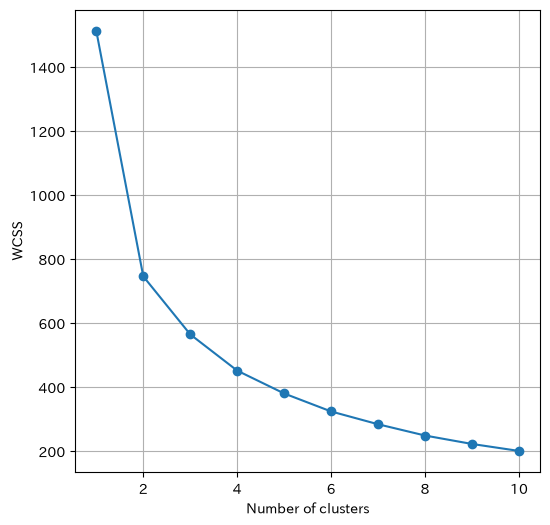

In [82]:
# エルボー法のグラフをプロット
plt.figure(figsize=(6, 6))

plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

plt.grid()
plt.show()

> 本データセットには4つの品種（BC・BT・GC・GT）という「正解」がありますが、エルボー法はラベルを一切見ずに、数値データの構造だけから適切なクラスタ数を推定しようとします。

上のグラフを見ると、肘（減少が急に緩やかになる点）は**4付近ではなく、2のあたり**にあるはずです。実際に、WCSSの減少量を数値で確認してみましょう。

In [83]:
# k=1→2→...→10 のそれぞれで、WCSSがどれだけ減ったかを確認する
decrease = -np.diff(wcss)
for k, d in zip(range(2, 11), decrease):
    print(f'k={k-1} → k={k}：WCSSの減少量 = {d:.1f}')

k=1 → k=2：WCSSの減少量 = 766.6
k=2 → k=3：WCSSの減少量 = 181.3
k=3 → k=4：WCSSの減少量 = 113.2
k=4 → k=5：WCSSの減少量 = 71.4
k=5 → k=6：WCSSの減少量 = 56.2
k=6 → k=7：WCSSの減少量 = 40.0
k=7 → k=8：WCSSの減少量 = 35.2
k=8 → k=9：WCSSの減少量 = 26.3
k=9 → k=10：WCSSの減少量 = 21.8


k=1から2に増やしたときの減少量が、他のどの増分よりも突出して大きいことが分かるはずです。つまり、**エルボー法は「2つのグループに分けるのが最も効果的」と示しています**。ただし、これが「4品種のうちの2つのグループ」を意味するとは限りません。実際にk=2のクラスタが何を捉えているのか、中身を確認してみましょう。

In [84]:
from sklearn.decomposition import PCA

# 標準化済みデータをPCAで2次元に次元削減
pca_for_elbow = PCA(n_components=2)
X_pca_std = pca_for_elbow.fit_transform(X_std)

# k=2 と k=4 、それぞれでk-meansクラスタリング
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_std)
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_std)

# クラスタ中心をPCA空間に射影（PCAは線形変換なので、この射影は数学的に正確）
centroids_k2_pca = pca_for_elbow.transform(kmeans_k2.cluster_centers_)
centroids_k4_pca = pca_for_elbow.transform(kmeans_k4.cluster_centers_)

# まず、k=2のクラスタが実際の品種とどう対応するか、中身を確認する
print('k=2のクラスタ内訳（実際の品種との対応）:')
print(pd.crosstab(pd.Series(kmeans_k2.labels_, name='cluster'), y))

k=2のクラスタ内訳（実際の品種との対応）:
tea      BC  BT  GC  GT
cluster                
0        30  22  22  24
1        12  20  20  18


表を見ると、**4品種のいずれもが、ほぼ均等に両方のクラスタへ分かれて入っている**ことが分かります。つまり、k=2のクラスタリングは「品種」を捉えているのではありません。では何を捉えているのでしょうか。次元削減の際に使ったPCAの主成分（PC1）が何を表しているかを調べてみましょう。

In [85]:
# PC1が何を表しているのか、「9元素の標準化値の合計（＝おおまかな抽出濃度の強さ）」との相関を確認する
total_concentration = X_std.sum(axis=1)
corr_pc1 = np.corrcoef(X_pca_std[:,0], total_concentration)[0,1]
print(f'PC1と「9元素の標準化濃度合計」との相関係数: {corr_pc1:.4f}')

print()
print('k=2の各クラスタにおける「9元素の標準化濃度合計」の平均値:')
print('cluster 0:', round(total_concentration[kmeans_k2.labels_==0].mean(), 2))
print('cluster 1:', round(total_concentration[kmeans_k2.labels_==1].mean(), 2))

PC1と「9元素の標準化濃度合計」との相関係数: 0.9997

k=2の各クラスタにおける「9元素の標準化濃度合計」の平均値:
cluster 0: -5.39
cluster 1: 7.55


相関係数がほぼ1.0であることから、**PC1は実質的に「9元素の合計濃度」を表す軸**であることが分かります。そして、k=2のクラスタは、この合計濃度が低いグループと高いグループに分かれているだけでした。

このデータセットは、同じ茶葉を**3段階の濃度（1%・2%・3%）×7段階の浸出時間**で抽出したものです。つまり「抽出条件（濃度・時間）による全体的な溶出量の違い」は、「品種による元素組成の違い」よりも大きな分散を持つ、ということをこの結果は示しています。**エルボー法・PCAのPC1・k=2のクラスタリングは、いずれも分散が最大の方向を捉える手法であるため、いずれも「品種」ではなく「抽出条件による濃度差」という、分析者が本来注目したい軸とは別の軸を拾ってしまった**わけです。

これは失敗ではなく、教師なし学習を実データに使う際によく起こる、重要な教訓です：**「データの中で最も分散が大きい方向」と「人間が知りたい違い」は、必ずしも一致しません。**

### 推測を、実際の抽出条件データで裏付ける

ここまでは「9元素の合計」という間接的な指標から、PC1が濃度に対応していると推測しました。今回のデータセットには実際の抽出条件（`conditions`：抽出濃度・抽出時間）が記録されているので、答え合わせをしてみましょう。

In [86]:
# PC1・k=2のクラスタが、実際の抽出濃度・抽出時間とどれだけ対応しているかを直接確認する
corr_pc1_conc = np.corrcoef(X_pca_std[:,0], conditions['Concentration_num'])[0,1]
corr_pc1_time = np.corrcoef(X_pca_std[:,0], conditions['time'])[0,1]
print(f'PC1と実際の抽出濃度(%)の相関係数: {corr_pc1_conc:.3f}')
print(f'PC1と実際の抽出時間(分)の相関係数: {corr_pc1_time:.3f}')

print()
print('k=2の各クラスタにおける、実際の抽出濃度・抽出時間の平均値:')
for c in sorted(set(kmeans_k2.labels_)):
    mask = kmeans_k2.labels_ == c
    print(f'cluster {c}: 抽出濃度平均={conditions["Concentration_num"][mask].mean():.2f}%　'
          f'抽出時間平均={conditions["time"][mask].mean():.1f}分　件数={mask.sum()}')

PC1と実際の抽出濃度(%)の相関係数: 0.772
PC1と実際の抽出時間(分)の相関係数: 0.514

k=2の各クラスタにおける、実際の抽出濃度・抽出時間の平均値:
cluster 0: 抽出濃度平均=1.53%　抽出時間平均=18.0分　件数=98
cluster 1: 抽出濃度平均=2.66%　抽出時間平均=33.7分　件数=70


推測どおり、PC1は実際の抽出濃度・抽出時間の両方と強い正の相関を持ち、k=2のクラスタは低濃度・短時間側と高濃度・長時間側に分かれていたことが確認できました。「9元素の合計」という間接的な手がかりから立てた仮説が、実際の実験条件データによって裏付けられたことになります。

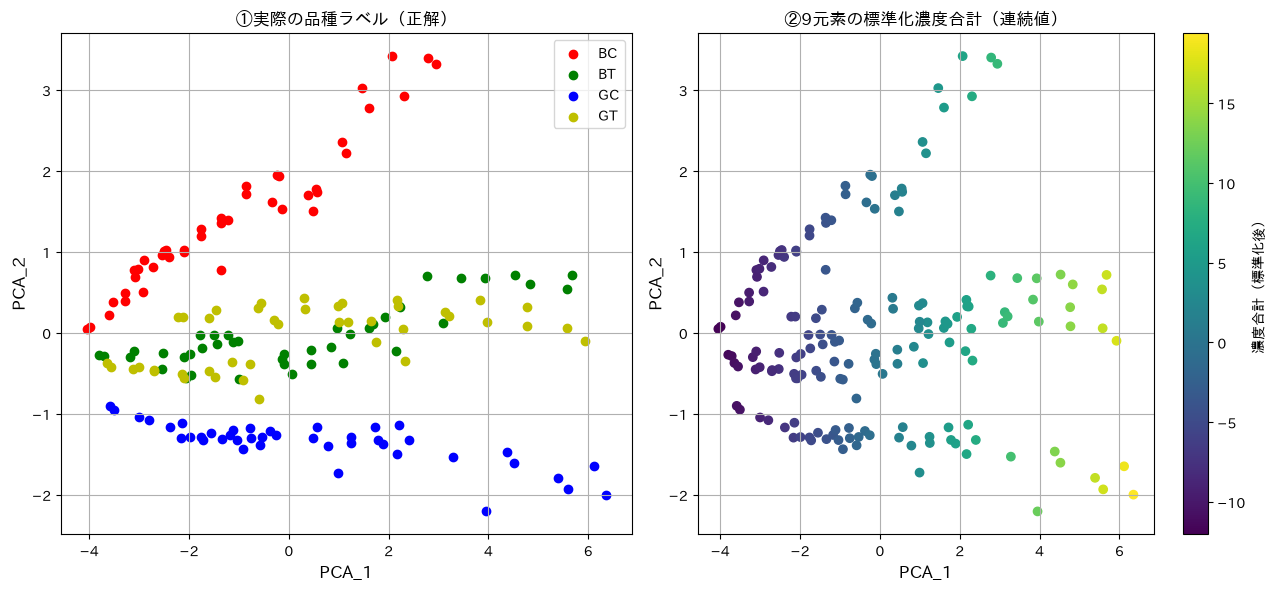

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(13,6))

# ① 実際の品種ラベルで色分け
tea_colors = {'BC':'r', 'BT':'g', 'GC':'b', 'GT':'y'}
for tea, c in tea_colors.items():
    pts = X_pca_std[y.values == tea]
    axes[0].scatter(pts[:,0], pts[:,1], color=c, label=tea)
axes[0].set_title('①実際の品種ラベル（正解）')
axes[0].legend()

# ② 9元素の標準化濃度合計で色分け（連続値、カラーバー）
sc = axes[1].scatter(X_pca_std[:,0], X_pca_std[:,1], c=total_concentration, cmap='viridis')
axes[1].set_title('②9元素の標準化濃度合計（連続値）')
plt.colorbar(sc, ax=axes[1], label='濃度合計（標準化後）')

for ax in axes:
    ax.set_xlabel('PCA_1', fontsize=12)
    ax.set_ylabel('PCA_2', fontsize=12)
    ax.grid()

plt.tight_layout()
plt.show()

②の図で、色（濃度合計）がPCA_1（横軸）ときれいに対応していることが確認できるはずです。一方、①の品種ラベルは、横軸（PCA_1）ではなく**縦軸（PCA_2）に沿ってある程度分かれて**います（特にGCが下側、BCが上側に偏っています）。つまり、**品種によるまとまりは、PC1ではなくPC2の方向に（部分的に）現れている**ということです。エルボー法やk=2のクラスタリングは分散最大の方向（PC1＝濃度）を優先的に拾うため、この品種の違いを見つけられなかったのです。

参考までに、k=4に指定した場合のクラスタ分けも確認しておきましょう。

In [89]:
print('k=4のクラスタ内訳（実際の品種との対応）:')
print(pd.crosstab(pd.Series(kmeans_k4.labels_, name='cluster'), y))

k=4のクラスタ内訳（実際の品種との対応）:
tea      BC  BT  GC  GT
cluster                
0        24  18  20  20
1         0  17  14  14
2         0   7   8   8
3        18   0   0   0


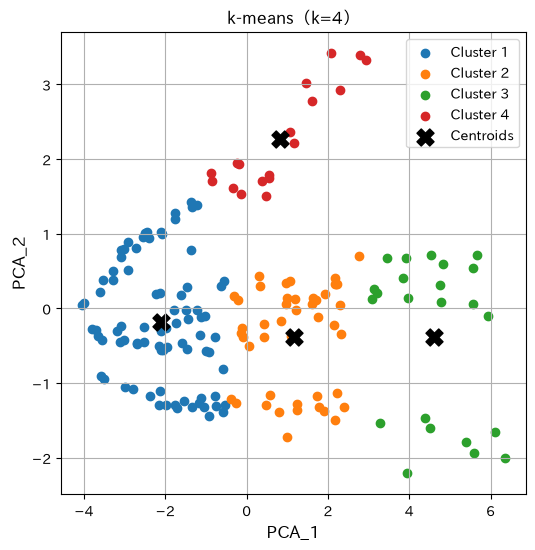

In [90]:
fig, ax = plt.subplots(figsize=(6,6))

for i in range(4):
    pts = X_pca_std[kmeans_k4.labels_ == i]
    ax.scatter(pts[:,0], pts[:,1], label=f'Cluster {i+1}')
ax.scatter(centroids_k4_pca[:,0], centroids_k4_pca[:,1], color='black', marker='X', s=150, label='Centroids')

ax.set_xlabel('PCA_1', fontsize=12)
ax.set_ylabel('PCA_2', fontsize=12)
ax.set_title('k-means（k=4）')
ax.legend()
ax.grid()
plt.show()

In [91]:
# 「BCだけのクラスタ（cluster3）」は、PC1（濃度）とPC2（品種の軸）のどちらで分離されているのかを確認する
for k in range(4):
    mask = kmeans_k4.labels_ == k
    print(f'cluster{k}: n={mask.sum():3d}  PC1平均={X_pca_std[mask,0].mean():5.2f}  '
          f'PC2平均={X_pca_std[mask,1].mean():5.2f}  内訳={y[mask].value_counts().to_dict()}')

# cluster3（BCのみ）に入らなかった残り24件のBCは、PC1・PC2それぞれどのあたりにいるか
pure_bc_cluster = [k for k in range(4) if set(y[kmeans_k4.labels_==k].unique()) == {'BC'}][0]
bc_in_pure = X_pca_std[kmeans_k4.labels_==pure_bc_cluster]
bc_elsewhere = X_pca_std[(y.values=='BC') & (kmeans_k4.labels_!=pure_bc_cluster)]
print()
print(f'純粋BCクラスタ内のBC(n={len(bc_in_pure)})：PC1平均={bc_in_pure[:,0].mean():.2f}　PC2平均={bc_in_pure[:,1].mean():.2f}')
print(f'他のクラスタに混ざったBC(n={len(bc_elsewhere)})：PC1平均={bc_elsewhere[:,0].mean():.2f}　PC2平均={bc_elsewhere[:,1].mean():.2f}')

cluster0: n= 82  PC1平均=-2.11  PC2平均=-0.18  内訳={'BC': 24, 'GT': 20, 'GC': 20, 'BT': 18}
cluster1: n= 45  PC1平均= 1.17  PC2平均=-0.38  内訳={'BT': 17, 'GT': 14, 'GC': 14}
cluster2: n= 23  PC1平均= 4.60  PC2平均=-0.38  内訳={'GT': 8, 'GC': 8, 'BT': 7}
cluster3: n= 18  PC1平均= 0.82  PC2平均= 2.26  内訳={'BC': 18}

純粋BCクラスタ内のBC(n=18)：PC1平均=0.82　PC2平均=2.26
他のクラスタに混ざったBC(n=24)：PC1平均=-2.60　PC2平均=0.81


結果を見ると、興味深いことが分かります。

* **cluster0・cluster1・cluster2の3つ**は、PC2平均がほぼ同じ（-0.18〜-0.38）で、PC1平均だけがきれいに低→中→高（-2.11 → 1.17 → 4.60）と並んでいます。つまり、この3つは**完全に「抽出濃度」で並んでいるだけ**で、品種の情報は使えていません（実際、それぞれの内訳はBT・GC・GTがほぼ均等に混ざっています）。
* 一方、**cluster3（BCだけのクラスタ）はPC1平均が0.82と中程度なのに、PC2平均だけが2.26と突出して高い**ことが分かります。つまり、このクラスタが分離できたのは**濃度（PC1）とは無関係に、PC2（品種に関わる軸）でBCの一部が際立って離れていたから**です。

つまり、前の解説（「濃度の高低が支配的で品種を分離できない」）は不正確でした。正しくは：**濃度（PC1）の影響は依然として強く、BT・GC・GTの3品種はその影響に隠れて全く分離できていませんが、BCについては、少なくとも一部のサンプルはPC2方向の品種差が濃度の影響を上回るほど大きく、k=4まで増やすことで分離に成功している**、ということです。

その証拠に、cluster3に入った18件のBCはPC2平均2.26と高い一方、他のクラスタに混ざった残り24件のBCはPC2平均0.81とやや低く、BT・GC・GTの水準（-0.18〜-0.38）に近づいています。**同じBCでも、PC2の値が特に高いサンプルだけが独立したクラスタとして検出され、そうでないサンプルは濃度クラスタに埋もれてしまう**、という境界線上の振る舞いが起きています。

品種そのものの違いをクラスタリングでより確実に捉えたい場合は、まず「抽出濃度の違い」を打ち消す前処理（例えば各サンプルを合計濃度で割って比率にする、といった正規化）をしたうえで、あらためてクラスタリングを行う必要があります。これは本ノートブックの範囲を超えるため、演習問題として扱います。

### ③　次元削減とクラスタリングを組み合わせる際の落とし穴

ここまでの通り、k-meansは9次元の標準化データ`X_std`の上でクラスタリングを行います。9次元のままではクラスタの分布を目で見て確認することができないため、UMAPで2次元に落とした図の上に、k-meansの結果を色分けして重ねたくなります。素直に書くと、次のようなコードになります。

```python
# 9次元でクラスタリング
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_std)

# 2次元に次元削減
X_umap = umap_model.fit_transform(X_std)

# クラスタ中心も2次元に変換してプロットに重ねる
centroids_umap = umap_model.transform(kmeans.cluster_centers_)
```

一見自然に見えますが、この最後の`umap_model.transform(kmeans.cluster_centers_)`という行に問題があります。

**なぜ問題なのか：** PCAは線形変換（回転・射影）なので、「9次元でのクラスタの重心をPCAで2次元に変換した点」と「2次元に変換したあとの点群の重心」は常に一致します（平均を取る操作と線形変換の順序を入れ替えても結果が同じになるためです）。ところが、**UMAPは非線形な変換**であり、しかも新しい点（今回でいうクラスタ中心）を埋め込む`transform()`は、元の学習データの近傍関係をもとにした近似的な位置づけにすぎません。そのため、**「9次元での重心をUMAPで変換した点」は、「2次元UMAP空間上でのそのクラスタの点群の実際の中心」とは一致しない**ことがあります。

実際に確認してみましょう。

In [38]:
# 9次元でk-meansクラスタリング
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_std)

# UMAPで2次元に次元削減（標準化済みデータ）
umap_model = UMAP(n_components=2, random_state=42)
X_umap_std = umap_model.fit_transform(X_std)

# クラスタ中心を2次元に変換
centroids_transformed = umap_model.transform(kmeans.cluster_centers_)

# 検証：各クラスタについて、「UMAP空間上での点群の実際の平均位置」と
# 「9次元の重心をtransform()で変換した位置」を比較する
for k in range(4):
    pts = X_umap_std[y_kmeans == k]
    actual_mean = pts.mean(axis=0)
    transformed = centroids_transformed[k]
    dist = np.linalg.norm(actual_mean - transformed)
    spread = pts.std(axis=0).mean()
    print(f'クラスタ{k}: 点の数={len(pts):3d}  '
          f'UMAP空間での実際の平均={np.round(actual_mean,2)}  '
          f'transform()で変換した重心={np.round(transformed,2)}  '
          f'ズレ={dist:.2f}（クラスタの広がり ~{spread:.2f}）')

クラスタ0: 点の数= 82  UMAP空間での実際の平均=[3.89 0.01]  transform()で変換した重心=[ 1.85 -0.11]  ズレ=2.04（クラスタの広がり ~2.44）
クラスタ1: 点の数= 45  UMAP空間での実際の平均=[-1.64 -2.27]  transform()で変換した重心=[-1.32 -2.66]  ズレ=0.50（クラスタの広がり ~1.47）
クラスタ2: 点の数= 23  UMAP空間での実際の平均=[-2.99 -3.57]  transform()で変換した重心=[-2.48 -4.91]  ズレ=1.43（クラスタの広がり ~1.04）
クラスタ3: 点の数= 18  UMAP空間での実際の平均=[11.67 -1.24]  transform()で変換した重心=[11.7  -1.73]  ズレ=0.49（クラスタの広がり ~0.30）


4つのクラスタのうち少なくともいくつかで、「ズレ」が「クラスタの広がり」と同程度か、それ以上になっているはずです。つまり、**プロット上の黒い「X」印（変換されたクラスタ中心）は、実際にはその色の点群の真ん中には来ない**ということです。これでは、生徒が図を見たときに「なぜXが群れの中心からズレているのか」と混乱するのも当然です。これが、UMAPとk-meansを単純に組み合わせたときに生じる「融合性のなさ」の正体です。

### ④　次元削減とクラスタリングを正しく「融合」させる

上記の問題を避ける最も簡単な方法は、**クラスタリングを行う空間と可視化する空間を一致させる**ことです。つまり、9次元でクラスタリングしてから2次元に無理やり中心を持ち込むのではなく、**先にUMAPで2次元に削減してから、その2次元空間の上でk-meansを実行する**という順番に変えます。

こうすれば、クラスタ中心はもともと2次元空間で計算されるため、`transform()`のような近似変換は一切不要になり、図とクラスタリングの結果が完全に対応します。

In [92]:
# ① 先にUMAPで2次元に次元削減（標準化済みデータ）
umap_model = UMAP(n_components=2, random_state=42)
X_umap_std = umap_model.fit_transform(X_std)

# ② 2次元に削減したあとの空間で、あらためてk-meansクラスタリングを実行
kmeans_on_umap = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans_on_umap = kmeans_on_umap.fit_predict(X_umap_std)

# クラスタ中心は、最初から2次元空間で計算されているので変換は不要
centroids_umap = kmeans_on_umap.cluster_centers_

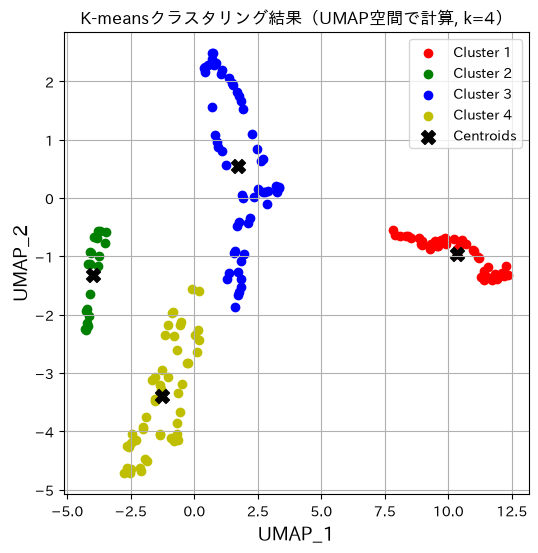

In [93]:
# クラスタリング結果のプロット（UMAP空間で計算・UMAP空間で可視化）
fig, ax = plt.subplots(figsize=(6,6))

colors = ['r', 'g', 'b','y']

for i in range(4):
    plt.scatter(X_umap_std[y_kmeans_on_umap == i, 0], X_umap_std[y_kmeans_on_umap == i, 1], 
                color=colors[i], label=f'Cluster {i+1}')

plt.scatter(centroids_umap[:, 0], centroids_umap[:, 1], 
            color='black', marker='X', s=100, label='Centroids')

plt.xlabel('UMAP_1', fontsize =14)
plt.ylabel('UMAP_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('K-meansクラスタリング結果（UMAP空間で計算, k=4）')

plt.show()

先ほどとは違い、黒い「X」印がそれぞれの色の点群のちょうど真ん中に来ているはずです。実際のラベルとの一致度も確認してみましょう。

In [94]:
# UMAP空間でのk-meansクラスタ番号と、実際の品種ラベルを突き合わせる
comparison_table_umap = pd.crosstab(pd.Series(y_kmeans_on_umap, name='KMeans(UMAP空間)クラスタ'), y)
comparison_table_umap

tea,BC,BT,GC,GT
KMeans(UMAP空間)クラスタ,,,,
0,42,0,0,0
1,0,0,20,0
2,0,16,22,18
3,0,26,0,24


9次元でクラスタリングしていた元のやり方（本ノートブック前半、cluster3）では、42件のBCのうち18件しか純粋なクラスタに入りませんでしたが、UMAP空間で先に次元削減してからクラスタリングすると、**42件全てのBCが1つのクラスタに完全に一致**しています。「クラスタリングと可視化の空間を一致させる」だけで、結果の解釈しやすさだけでなく、実際の分離性能そのものも改善したことになります。

### ⑤　【発展】より適切な代替手法：HDBSCAN

④の方法でも、**k-meansは「クラスタは球状（円形）に分布する」ことを仮定するアルゴリズムである**という本質的な制約は残っています。UMAPの埋め込みは、必ずしも球状にきれいに分かれるとは限らず、細長い形や三日月型のクラスタになることも多いため、k-meansとの相性が完璧というわけではありません。

そこで、UMAPと組み合わせる手法として、UMAPの開発者自身も推奨している**HDBSCAN**（Hierarchical Density-Based Spatial Clustering of Applications with Noise）を紹介します。HDBSCANには、k-meansと違う次の特徴があります。

* **クラスタ数`k`を事前に指定する必要がない**：データの密度が高い領域を自動的にクラスタとして検出します。
* **球状を仮定しない**：密度でつながっている領域であれば、どんな形のクラスタでも検出できます。
* **「どのクラスタにも属さない」点（ノイズ）を許容する**：無理に全ての点をどこかのクラスタに割り当てません。

scikit-learn 1.3以降では`sklearn.cluster.HDBSCAN`として標準搭載されています。

In [95]:
from sklearn.cluster import HDBSCAN

# HDBSCANをUMAP空間に適用（クラスタ数の指定は不要）
hdbscan_model = HDBSCAN(min_cluster_size=8)
y_hdbscan = hdbscan_model.fit_predict(X_umap_std)

n_clusters_found = len(set(y_hdbscan)) - (1 if -1 in y_hdbscan else 0)
n_noise = int((y_hdbscan == -1).sum())
print(f'HDBSCANが自動的に検出したクラスタ数: {n_clusters_found}')
print(f'どのクラスタにも属さないと判定された点（ノイズ）の数: {n_noise}')

HDBSCANが自動的に検出したクラスタ数: 5
どのクラスタにも属さないと判定された点（ノイズ）の数: 6


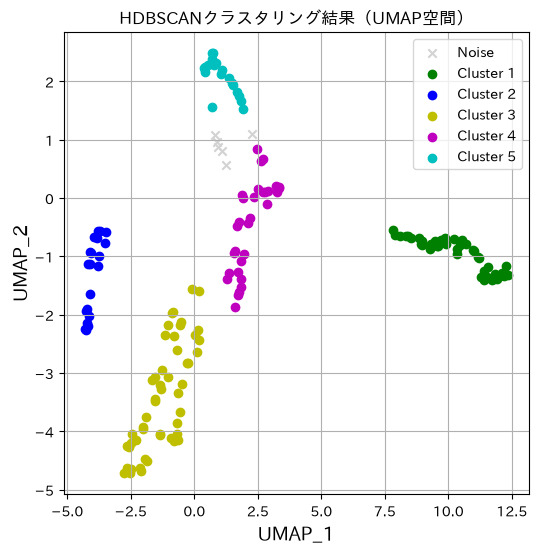

In [96]:
# HDBSCANの結果のプロット
fig, ax = plt.subplots(figsize=(6,6))

unique_labels = sorted(set(y_hdbscan))
palette = ['r', 'g', 'b', 'y', 'm', 'c']

for i, lab in enumerate(unique_labels):
    mask = (y_hdbscan == lab)
    if lab == -1:
        plt.scatter(X_umap_std[mask, 0], X_umap_std[mask, 1], 
                    color='lightgray', label='Noise', marker='x')
    else:
        plt.scatter(X_umap_std[mask, 0], X_umap_std[mask, 1], 
                    color=palette[i % len(palette)], label=f'Cluster {lab+1}')

plt.xlabel('UMAP_1', fontsize =14)
plt.ylabel('UMAP_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('HDBSCANクラスタリング結果（UMAP空間）')

plt.show()

In [97]:
# HDBSCANのクラスタ番号と、実際の品種ラベルを突き合わせる
comparison_table_hdbscan = pd.crosstab(pd.Series(y_hdbscan, name='HDBSCANクラスタ'), y)
comparison_table_hdbscan

tea,BC,BT,GC,GT
HDBSCANクラスタ,,,,
-1,0,0,1,5
0,42,0,0,0
1,0,0,20,0
2,0,26,0,24
3,0,16,3,12
4,0,0,18,1


### ⑥　3つの結果を比べて分かること

ここまでで、同じ9元素のデータから、3通りの方法でクラスタリングを行いました。

1. **9次元でk-means（本ノートブック前半）**：4クラスタに分けたが、BC以外は複数のクラスタに混ざり合った。
2. **UMAPの2次元空間でk-means（④）**：BCはきれいに分離できたが、依然として「4つに分ける」という前提を人間側が与えている。
3. **UMAPの2次元空間でHDBSCAN（⑤）**：クラスタ数を一切指定していないにもかかわらず、データが自律的にグループ分けされる。

3の結果が「4」にならなかった場合（多くの場合、BCとそれ以外、のような少ない数に落ち着くはずです）、それはHDBSCANの失敗ではなく、**「元素組成という情報だけからは、4品種のうち少なくとも一部は明確な密度差を持って分離できない」という、データについての正直な発見**です。k-meansは指定すれば必ず4つに分けてくれますが、それは「本当に4つの塊がある」ことを意味しません。

分類編（`Scikit-learn-5_Classification.ipynb`）でランダムフォレスト等が高い正解率を達成できたのは、**ラベルという追加情報を使えたから**です。教師なし学習だけでは、ラベルなしに同じ精度で4品種を再現することは一般には困難であり、むしろそれを正直に示すHDBSCANのような手法の方が、実務上は誤解を招きにくい場合があります。

# 4. 抽出条件の影響を取り除いて、あらためて品種の違いを探す

ここまでの分析で、元素分析値（9元素）だけを使った次元削減・クラスタリングは、品種ではなく「抽出濃度・抽出時間」という交絡要因を強く反映してしまうことが分かりました。幸い、今回のデータセットにはこの交絡要因（`conditions`）が実際に記録されています。これをどう活用すればよいでしょうか。

## 0. まず試してみる：説明変数にそのまま追加したらどうなるか

交絡要因が分かっているなら、「取り除く」のではなく、**そのまま説明変数（X）に追加すればよいのでは**、という発想は自然です。9元素に抽出濃度・抽出時間を加えた11次元でクラスタリングし直すとどうなるか、まず試してみましょう。

In [98]:
# 9元素 + 抽出濃度 + 抽出時間 の11次元でクラスタリング
X_with_conditions = X.copy()
X_with_conditions['Concentration_num'] = conditions['Concentration_num']
X_with_conditions['time'] = conditions['time']

X_with_conditions_std = StandardScaler().fit_transform(X_with_conditions)

pca_11d = PCA(n_components=2).fit(X_with_conditions_std)
print('11次元データのPCA寄与率:', np.round(pca_11d.explained_variance_ratio_, 3))

kmeans_11d = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_with_conditions_std)
print()
print('11次元データでのk=4クラスタリング結果（実際の品種との対応）:')
print(pd.crosstab(pd.Series(kmeans_11d.labels_, name='cluster'), y))

11次元データのPCA寄与率: [0.666 0.12 ]

11次元データでのk=4クラスタリング結果（実際の品種との対応）:
tea      BC  BT  GC  GT
cluster                
0        23  18  18  20
1         0   7   8   8
2         0  17  16  14
3        19   0   0   0


9元素だけのとき（本ノートブック前半、純粋なクラスタはBCのみ18件）と、ほとんど変わらない結果になっているはずです。**抽出濃度・抽出時間を特徴量として追加するだけでは、問題は解決しません。**

理由を考えてみましょう。k-meansやPCAは、与えられた特徴量の中で**分散が最も大きい方向**を優先的に捉えます。抽出濃度・抽出時間をそのまま追加すると、（1）これらの変数自体の分散が大きいことに加え、（2）9元素のほとんどが抽出濃度・抽出時間と強く相関しているため、「濃度・時間の方向」と「元素の変動の大部分」が重なり合ってしまいます。その結果、**交絡要因を追加しても、交絡要因が支配的な方向であること自体は変わらない**のです。むしろ、次元が増えた分、品種による違い（相対的に小さな変動）はさらに埋もれやすくなります。

必要なのは「追加」ではなく「除去」です。次の②で、抽出濃度・抽出時間の影響を統計的に取り除く（残差化する）方法を試します。

## 2. 残差化（抽出条件の影響の除去）

考え方はシンプルです。各元素について、「抽出濃度・抽出時間から予測できる部分」を線形回帰で求め、実際の値からその予測値を差し引きます。この「残差（Residual）」には、抽出条件だけでは説明できない、それ以外の要因（品種による違いを含む）が残ります。

In [99]:
from sklearn.linear_model import LinearRegression

# 各元素（標準化後）を、抽出濃度・抽出時間で回帰し、残差を求める
X_resid = np.zeros_like(X_std)

for j in range(X_std.shape[1]):
    lr = LinearRegression().fit(conditions, X_std[:, j])
    X_resid[:, j] = X_std[:, j] - lr.predict(conditions)

X_resid = pd.DataFrame(X_resid, columns=X.columns)

# 残差化がうまくいったか確認：残差の合計と抽出濃度の相関が、ほぼ0になっているはず
corr_check = np.corrcoef(X_resid.sum(axis=1), conditions['Concentration_num'])[0,1]
print(f'残差の合計と抽出濃度の相関係数: {corr_check:.6f}（残差化前は約0.78でした）')

残差の合計と抽出濃度の相関係数: -0.000000（残差化前は約0.78でした）


相関係数がほぼ0になっており、抽出濃度・抽出時間の影響がきちんと取り除けたことが確認できます。この残差データ`X_resid`を使って、PCAとk-meansをやり直してみましょう。

In [100]:
# 残差データでPCA
pca_resid = PCA(n_components=2)
X_pca_resid = pca_resid.fit_transform(X_resid)

print('残差データのPCA寄与率:', np.round(pca_resid.explained_variance_ratio_, 3))

残差データのPCA寄与率: [0.53  0.232]


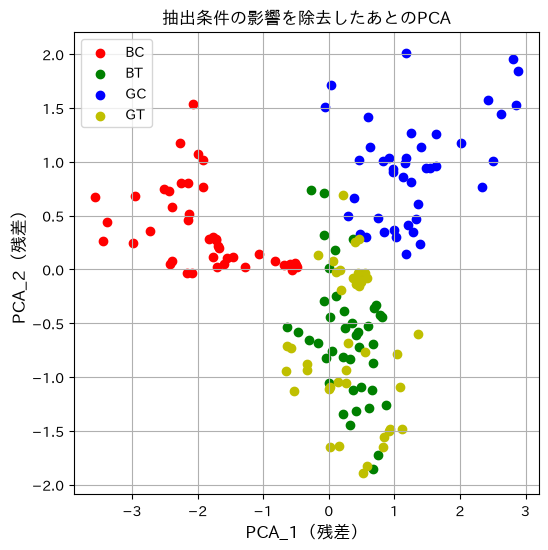

In [101]:
# 残差データのPCA散布図（実際の品種ラベルで色分け）
fig, ax = plt.subplots(figsize=(6,6))

for tea, c in tea_colors.items():
    pts = X_pca_resid[y.values == tea]
    ax.scatter(pts[:,0], pts[:,1], color=c, label=tea)

ax.set_xlabel('PCA_1（残差）', fontsize=12)
ax.set_ylabel('PCA_2（残差）', fontsize=12)
ax.set_title('抽出条件の影響を除去したあとのPCA')
ax.legend()
ax.grid()
plt.show()

ここまでのPCA図（濃度で色分けしたときにPC1ときれいに対応していた図）と見比べてみましょう。品種（色）ごとのまとまりが、以前よりもはっきり見えるようになっているはずです。

## 3. 残差データでのk-meansクラスタリング

品種数（4）に合わせてk-meansを実行し、実際の品種との対応を確認します。

In [102]:
kmeans_resid = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_resid)

print('残差データでのk=4クラスタリング結果（実際の品種との対応）:')
print(pd.crosstab(pd.Series(kmeans_resid.labels_, name='cluster'), y))

残差データでのk=4クラスタリング結果（実際の品種との対応）:
tea      BC  BT  GC  GT
cluster                
0        35   0   0   0
1         7  19   2  24
2         0  23   0  18
3         0   0  40   0


9次元の生データでのk=4（本ノートブック前半）では、純粋なクラスタはBCのみ・18件でした。残差データではどうでしょうか。おそらく、BCに加えてGC（グリーンセイロン）についても、かなり純粋なクラスタが得られているはずです。一方で、BT（ブラックトルコ）とGT（グリーントルコ）は、依然として混ざりやすい傾向が残ります。

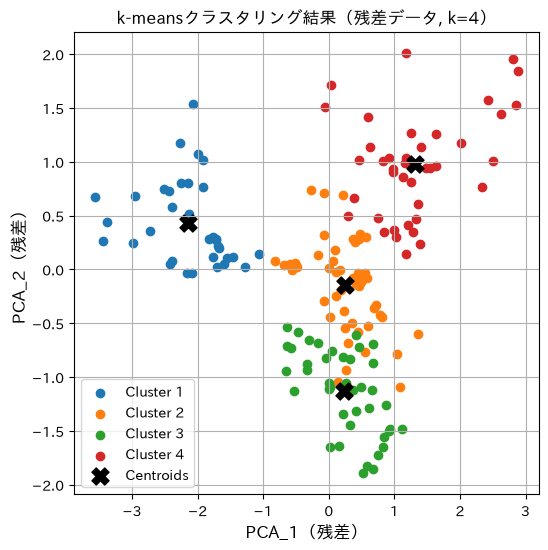

In [103]:
# 残差データでのクラスタリング結果を可視化
fig, ax = plt.subplots(figsize=(6,6))

for i in range(4):
    pts = X_pca_resid[kmeans_resid.labels_ == i]
    ax.scatter(pts[:,0], pts[:,1], label=f'Cluster {i+1}')

centroids_resid_pca = pca_resid.transform(kmeans_resid.cluster_centers_)
ax.scatter(centroids_resid_pca[:,0], centroids_resid_pca[:,1], color='black', marker='X', s=150, label='Centroids')

ax.set_xlabel('PCA_1（残差）', fontsize=12)
ax.set_ylabel('PCA_2（残差）', fontsize=12)
ax.set_title('k-meansクラスタリング結果（残差データ, k=4）')
ax.legend()
ax.grid()
plt.show()

## 4. まとめ：交絡要因を除去したことで見えてきたもの

* **BC（ブラックセイロン）・GC（グリーンセイロン）** は、抽出条件の影響を取り除くと、教師なし学習だけでもかなり明確に分離できるようになりました。「セイロン」産の茶葉は、加工方法（黒茶・緑茶）によらず、元素組成に品種特有の特徴が強く現れている可能性があります。
* **BT（ブラックトルコ）・GT（グリーントルコ）** は、抽出条件を除去した後も、互いに混ざりやすい傾向が残ります。「トルコ」産の黒茶・緑茶は、元素組成だけでは区別が難しいのかもしれません。

この「セイロン産は分離しやすく、トルコ産は分離しにくい」という見立てはこのデータだけからの示唆であり、断定するには追加の検証（他の産地のデータとの比較や、化学的な背景の調査）が必要です。あくまで教師なし学習の結果から得られた**仮説**として捉えてください。

**この節全体を通じた教訓：** 教師なし学習で「知りたい違い」がうまく捉えられないとき、原因はアルゴリズムの性能不足とは限りません。今回のように、**データの中に、分析者が意図しない別の強い変動要因（交絡要因）が隠れている**ことがよくあります。今回は幸い、その交絡要因（抽出濃度・抽出時間）が実験条件として記録されていたため、統計的に取り除いて対処できました。もし記録されていなかったら、この改善はできなかったでしょう。**データを集める段階で、後々交絡要因になりうる条件（今回で言う抽出濃度・時間のような）を記録しておくことの重要性**も、この分析からの実践的な教訓です。

---

# 5. まとめと演習問題

## まとめ

本ノートブックでは、次のことを学びました。

* 欠損値（抽出条件が記録されていない79件）を`dropna()`で除去する前処理
* PCA・t-SNE・UMAPによる次元削減と、それぞれの標準化前後での結果の違い（特にPCAでは、標準化しないと1つの元素（K）だけで結果が決まってしまうことを実際の数値で確認しました）
* 寄与率・累積寄与率によるPCAの情報保持量の確認
* 階層クラスタリング（デンドログラム）とk-means（エルボー法によるクラスタ数の検討）
* **エルボー法・PCAが拾う「分散最大の方向」と「知りたい違い（品種）」が一致するとは限らないこと**：本データセットではエルボー法がk=2を示しましたが、その内訳を実際に確認すると品種とは無関係で、実際には「抽出濃度・抽出時間による溶出量の違い」を捉えているだけでした（実際の抽出条件データとの相関で裏付け済み）。品種による違いはPC2方向に現れており、教師なし学習の結果を鵜呑みにせず中身を検証することの重要性を確認しました
* **次元削減とクラスタリングを組み合わせる際の落とし穴**：9次元でクラスタリングしたあとにUMAPの`transform()`でクラスタ中心だけを2次元に変換すると、実際の点群の中心とズレてしまうことを、実際の数値で確認しました
* **正しい「融合」のさせ方**：先にUMAPで2次元に削減し、その空間の中でk-meansを実行することで、可視化とクラスタリングが矛盾しない結果を得る方法
* **より適切な代替手法としてのHDBSCAN**：クラスタ数を事前に指定せず、データの密度構造から自律的にクラスタを発見する手法と、k-meansとの結果の違い
* デンドログラムの色分けが「品種数」を意味するとは限らないこと。scipyの既定の色分けルールと、実際に色が何を捉えているかの検証方法
* **交絡要因（抽出条件）を線形回帰で除去（残差化）し、あらためて次元削減・クラスタリングを行う方法**：抽出濃度・抽出時間の影響を取り除くことで、BC・GCについては教師なし学習でもかなり明確な分離が得られるようになりました。一方でBT・GTは依然として分離が難しく、交絡要因の除去だけでは全ての課題が解決するわけではないことも確認しました
* 教師なしクラスタリングの結果を、実際のラベルと突き合わせて「どれくらい正解に近いか」を確認する方法、およびその結果が教師あり学習（分類編）ほど明確ではないこと

## 本ノートブックでは扱っていないこと（今後の課題）

1. **シルエット分析など、エルボー法以外のクラスタ数決定手法は扱っていません。**
2. **t-SNE・UMAPの主要パラメータ（`perplexity`・`n_neighbors`など）を変えた比較は行っていません。**
3. **階層クラスタリングの`method`（linkage法）を変えた比較は行っていません。**
4. **HDBSCANの`min_cluster_size`・`min_samples`を変えた比較は行っていません。**
5. **なぜBT・GT（トルコ産）がBC・GC（セイロン産）より分離しにくいのかについて、化学的な背景の調査は行っていません。**

## 演習問題

1. 残差化した後のデータ（`X_resid`）に対してHDBSCANを適用し、k-meansの結果（本編4章）と比較してみましょう。BT・GTの分離は改善するでしょうか。
2. t-SNEの`perplexity`を5・30・50と変えて、プロットの見た目がどう変わるか比較してみましょう。
3. UMAPの`n_neighbors`を5・15・50と変えて、同様に比較してみましょう。
4. 階層クラスタリングの`method`を`'ward'`から`'average'`や`'complete'`に変えて、デンドログラムの形がどう変わるか確認してみましょう。
5. `HDBSCAN`の`min_cluster_size`を5・15・25と変えて、検出されるクラスタ数とノイズ点の数がどう変化するか確認してみましょう。
6. 抽出濃度（`Concentration_num`）だけを回帰で除去し、抽出時間はそのまま残した場合、品種の分離はどう変わるか確認してみましょう。